In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
robin_path = '/blue/yanjun.li/sjiang43.johnshopkins/pub_version/v3_1119/SMARTBind-internal/revision/data/robin/robin_processed'

In [ ]:
rna_data = []
for f in os.listdir(robin_path):
    true_pd = pd.read_csv(os.path.join(robin_path, f, 'raw/data_set.csv'))
    true_binders = true_pd['compound_iso_smiles'].tolist()
    target_sequence = true_pd['target_sequence'].iloc[0]
    
    if 'Hairpin' in f:
        motif_type = 'Hairpin'
    elif 'G-quadruplex' in f:
        motif_type = 'G-quadruplex'
    elif 'Pseudoknot' in f:
        motif_type = 'Pseudoknot'
    elif 'Triple_helix' in f:
        motif_type = 'Triple_helix'
    elif 'Three-way_junction' in f:
        motif_type = 'Three-way_junction'
    else:
        motif_type = 'Other'
    
    rna_data.append({
        'name': f,
        'motif': motif_type,
        'true_binders': len(true_binders)
    })
    print(f'Processing {f} with {len(true_binders)} true binders, motif: {motif_type}')

df = pd.DataFrame(rna_data)

Processing KLF6_wt_Hairpin with 74 true binders, motif: Hairpin
Processing BCL_XL_SS_Hairpin with 205 true binders, motif: Hairpin
Processing ZTP_Pseudoknot with 171 true binders, motif: Pseudoknot
Processing MALAT1_Triple_helix with 191 true binders, motif: Triple_helix
Processing Pre_miR_31_Hairpin with 82 true binders, motif: Hairpin
Processing Zika3PrimeUTR_G-quadruplex with 185 true binders, motif: G-quadruplex
Processing KLF6_mut_Hairpin with 92 true binders, motif: Hairpin
Processing RRE2B_MeA_Hairpin with 234 true binders, motif: Hairpin
Processing PreQ1_Pseudoknot with 167 true binders, motif: Pseudoknot
Processing AKTIP_G-quadruplex with 223 true binders, motif: G-quadruplex
Processing Pro_wt_Hairpin with 69 true binders, motif: Hairpin
Processing EWSR1_G-quadruplex with 292 true binders, motif: G-quadruplex
Processing Pre_miR_21_Hairpin with 78 true binders, motif: Hairpin
Processing Glutamine_RS_Three-way_junction with 70 true binders, motif: Three-way_junction
Processing R

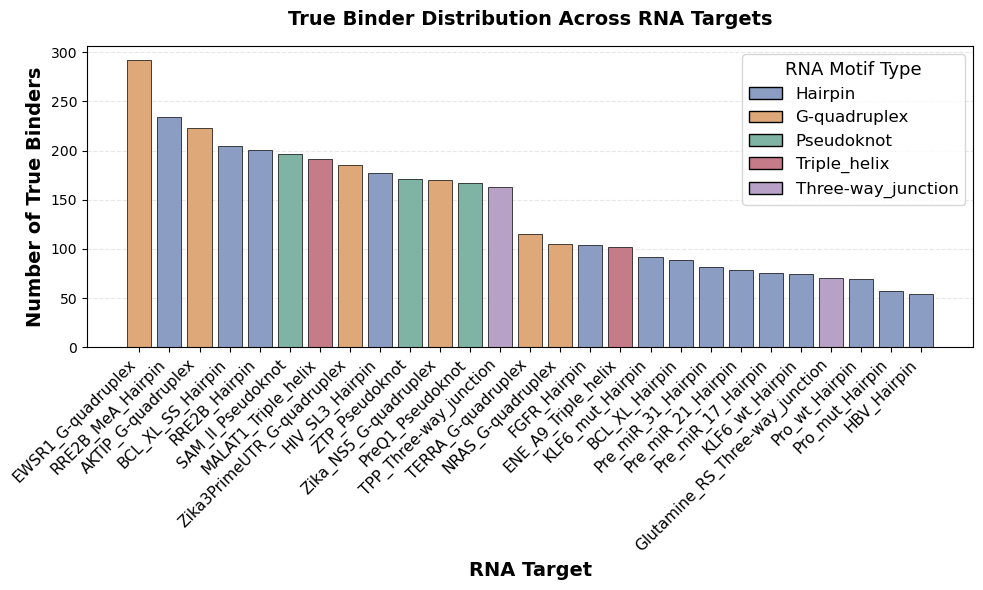

In [ ]:
motif_colors = {
    'Hairpin': '#8B9DC3',          
    'G-quadruplex': '#DFA878',     
    'Pseudoknot': '#7FB3A4',       
    'Triple_helix': '#C67B88',     
    'Three-way_junction': '#B8A1C7'
}

fig, ax = plt.subplots(figsize=(10, 6))

df_sorted = df.sort_values('true_binders', ascending=False)

colors = [motif_colors.get(m, '#95A5A6') for m in df_sorted['motif']]

bars = ax.bar(range(len(df_sorted)), df_sorted['true_binders'], color=colors, edgecolor='black', linewidth=0.5)

ax.set_xticks(range(len(df_sorted)))
ax.set_xticklabels(df_sorted['name'], rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Number of True Binders', fontsize=14, weight='bold')
ax.set_xlabel('RNA Target', fontsize=14, weight='bold')
ax.set_title('True Binder Distribution Across RNA Targets', fontsize=14, weight='bold', pad=15)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=motif, edgecolor='black') 
                   for motif, color in motif_colors.items() if motif in df['motif'].values]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, title='RNA Motif Type', title_fontsize=13)

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('true_binders_bar_plot.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
motif_counts = df['motif'].value_counts()
print("\nMotif distribution:")
print(motif_counts)


Motif distribution:
motif
Hairpin               14
G-quadruplex           6
Pseudoknot             3
Triple_helix           2
Three-way_junction     2
Name: count, dtype: int64


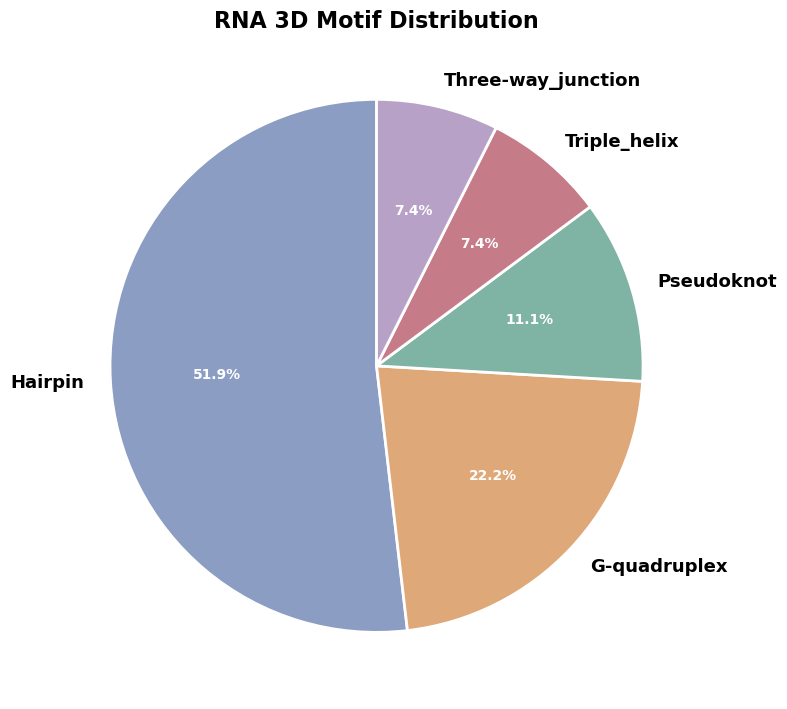

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))

motif_data = df['motif'].value_counts()
labels = motif_data.index.tolist()
sizes = motif_data.values.tolist()
colors_pie = [motif_colors[label] for label in labels]

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie, 
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'fontsize': 13, 'weight': 'bold'},
                                    wedgeprops={'edgecolor': 'white', 'linewidth': 2})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)

ax.set_title('RNA 3D Motif Distribution', fontsize=16, weight='bold', pad=1)

plt.tight_layout()
plt.savefig('motif_pie_chart.png', dpi=600, bbox_inches='tight')
plt.show()